# Load Libraries

In [961]:
import requests
import pandas as pd
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from libpysal import weights  
from splot.libpysal import plot_spatial_weights
import esda
from splot.esda import (
    plot_moran, moran_scatterplot, lisa_cluster, plot_local_autocorrelation,
)


## Data Documentation

For the project we merged 2 data sets:
- data with the name and spatial extent of all Danish municipalities
- data with the number of crimes in all Danish municipalities at years 2007 and 2025

The crime rates dataset were retrieved using the statbank API from table STRAF11, from the statistics denmark website.
Each Danish minicipacipality contains the type of crimes commited and the total number of these crimes, An example of how they are stuctured is shown below:


- All types of Crimes:
    - All criminal law crimes:
        - Sexual
        - Violent
        - Property
        - Other criminal law crimes
    - All Special law crimes

For our spartial analysis, we only used the total number of all crimes commited per municipality.


# Data Collection

### Retrieve the table structure and variables

In [962]:
print("Available population data table (BY2):")
response = requests.get("https://api.statbank.dk/v1/tableinfo/BY2")
for var in response.json()['variables']:
    print(var['id'])

Available population data table (BY2):
KOMK
BYST
ALDER
KØN
Tid


In [963]:
print("Available crime data table (STRAF11):")
response = requests.get("https://api.statbank.dk/v1/tableinfo/STRAF11")
for var in response.json()['variables']:
    print(var['id'])

Available crime data table (STRAF11):
OMRÅDE
OVERTRÆD
Tid


### Retrieve the population per municipality dataset from API (2010 and 2025)

In [964]:
url = "https://api.statbank.dk/v1/data"

payload = {
    "table": "BY2",
    "format": "CSV",
    "variables": [
        {"code": "Tid", "values": ["2010","2025"]},
        {"code": "KOMK", "values": ["*"]},
    ]
}

response = requests.post(url, json=payload)

if response.status_code == 200:
    with open("./data/population_data.csv", "w", encoding="utf-8") as f:
        f.write(response.text)
    print("Population data saved successfully")
else:
    print("Error:", response.status_code, response.text)

Population data saved successfully


In [965]:
population = pd.read_csv("./data/population_data.csv", sep=";")
population = population.rename(columns={"TID": "year", "KOMK": "name", "INDHOLD": "population"})
population

,year,name,population
0,2010,København,528208
1,2010,Frederiksberg,96718
2,2010,Dragør,13564
3,2010,Tårnby,40383
4,2010,Albertslund,27730
...,...,...,...
193,2025,Morsø,19520
194,2025,Rebild,30942
195,2025,Thisted,42698
196,2025,Vesthimmerlands,35818


In [966]:
# check shape
population.shape

(198, 3)

In [967]:
# check the number of municipalities
population['name'].nunique()

99

In [968]:
# check for null values
population.isna().sum()

year          0
name          0
population    0
dtype: int64

### Retrieve the crime rates dataset from API (2010 and 2025)

In [969]:
url = "https://api.statbank.dk/v1/data"

payload = {
    "table": "STRAF11",
    "format": "CSV",
    "variables": [
        {"code": "Tid", "values": ["2010k1","2010k2","2010k3","2010k4","2025k1","2025k2","2025k3","2025k4"]},
        {"code": "OMRÅDE", "values": ["*"]},
      # {"code": "OVERTRÆD", "values": ["*"]} all crime types
    ]
}

response = requests.post(url, json=payload)

if response.status_code == 200:
    with open("./data/crime_rate.csv", "w", encoding="utf-8") as f:
        f.write(response.text)
    print("Crime data saved successfully")
else:
    print("Error:", response.status_code, response.text)

Crime data saved successfully


In [970]:
# Load the crime rate data into a DataFrame and rename columns
crimes = pd.read_csv("./data/crime_rate.csv", sep=";")
crimes.head()

,TID,OMRÅDE,INDHOLD
0,2010K1,Hele landet,122116
1,2010K1,Region Hovedstaden,47990
2,2010K1,København,22404
3,2010K1,Frederiksberg,2072
4,2010K1,Dragør,149


In [971]:
# check the number of municipalities
crimes['OMRÅDE'].nunique()

106

In [972]:
# check shape
crimes.shape

(848, 3)

In [973]:
# check for null values
crimes.isna().sum()

TID        0
OMRÅDE     0
INDHOLD    0
dtype: int64

### Load geometries per municipality

In [974]:
geom = gpd.read_file("data/municipalities_dk.gpkg")
geom = gpd.GeoDataFrame(geom, geometry="geometry")
geom.head()

,kommunekode,navn,region,municipal_id,geometry
0,0370,Næstved,None,370,"MULTIPOLYGON (((672902.45 6143708.87, 672880.8..."
1,0330,Slagelse,None,330,"MULTIPOLYGON (((654675.25 6154223.21, 654636.5..."
2,0766,Hedensted,None,766,"MULTIPOLYGON (((563379.45 6175110.36, 563346.5..."
3,0510,Haderslev,None,510,"MULTIPOLYGON (((516449.61 6137370.13, 516423.3..."
4,0550,Tønder,None,550,"MULTIPOLYGON (((482562.4 6122027.62, 482507.56..."


In [975]:
# check projection: EPSG:25832 -> meters
geom.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Denmark - onshore and offshore; Germany - onshore and offshore; Italy - onshore and offshore; Norway including Svalbard - onshore and offshore; Spain - offshore.
- bounds: (6.0, 36.53, 12.01, 84.01)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [976]:
# check shape
geom.shape

(99, 5)

In [977]:
# check for null-values
geom.isna().sum()

kommunekode      0
navn             0
region          99
municipal_id     0
geometry         0
dtype: int64

# Data Preprocessing

In [978]:
'''
First, we translated the column names and filter the data getting only the rows with the total crimes.
Then we grouped each year quarter into years and calculated the total number of crimes per year. 
For example, we computed the sum of total crimes for 2007 as 2007k1 + 2007k2 + 2007k3 + 2007k4 and we did the same for 2025.
'''

crimes.columns = ["quarterYear", "municipality", "totalCrimes"]

crimes["year"] = crimes["quarterYear"].str[:4]
crimes = (
    crimes.groupby(["municipality", "year"], as_index=False)["totalCrimes"]
    .sum()
)
crimes = crimes[
    ["municipality", "year", "totalCrimes"]
]
crimes.shape

(212, 3)

In [979]:
# Ensure both year columns are integers
crimes["year"] = crimes["year"].astype(int)
population["year"] = population["year"].astype(int)

# Merge Datasets

In [980]:
# Merge poulation and crime dataframes
crimes_population_df = pd.merge(
    crimes,
    population,
    left_on=["municipality", "year"],
    right_on=["name", "year"],
    how="inner"
).drop(columns=["name"])

# removing 'Christiansø' because is not an municipality
crimes_population_df = crimes_population_df[crimes_population_df["municipality"] != "Christiansø"]

In [981]:
# check shape
crimes_population_df.shape

(196, 4)

In [982]:
## Kept only the name and geometry columns while translating the name column to English
geom = geom[["navn", "geometry"]]
geom.columns = ["name", "geometry"]

In [983]:
# merge geometries with crime+population dataset
gdf = geom.merge(crimes_population_df, left_on="name", right_on="municipality")
gdf = gdf[["municipality", "year", "totalCrimes","population", "geometry"]]
gdf = gdf.rename(columns={"population": "totalPopulation"})
gdf.head()

,municipality,year,totalCrimes,totalPopulation,geometry
0,Næstved,2010,6192,81112,"MULTIPOLYGON (((672902.45 6143708.87, 672880.8..."
1,Næstved,2025,5821,84895,"MULTIPOLYGON (((672902.45 6143708.87, 672880.8..."
2,Slagelse,2010,7450,77475,"MULTIPOLYGON (((654675.25 6154223.21, 654636.5..."
3,Slagelse,2025,5571,80481,"MULTIPOLYGON (((654675.25 6154223.21, 654636.5..."
4,Hedensted,2010,2608,45982,"MULTIPOLYGON (((563379.45 6175110.36, 563346.5..."


In [984]:
# check shape
gdf.shape

(196, 5)

In [985]:
print("Total crimes in denmark (2010): ", gdf[gdf['year'] == 2010]['totalCrimes'].sum())
print("Total crimes in denmark (2025): ", gdf[gdf['year'] == 2025]['totalCrimes'].sum())

print("Total Population in denmark (2010): ", gdf[gdf['year'] == 2010]['totalPopulation'].sum())
print("Total Population in denmark (2025): ", gdf[gdf['year'] == 2025]['totalPopulation'].sum())

Total crimes in denmark (2010):  527380
Total crimes in denmark (2025):  378851
Total Population in denmark (2010):  5534637
Total Population in denmark (2025):  5992644


# Plot geometries

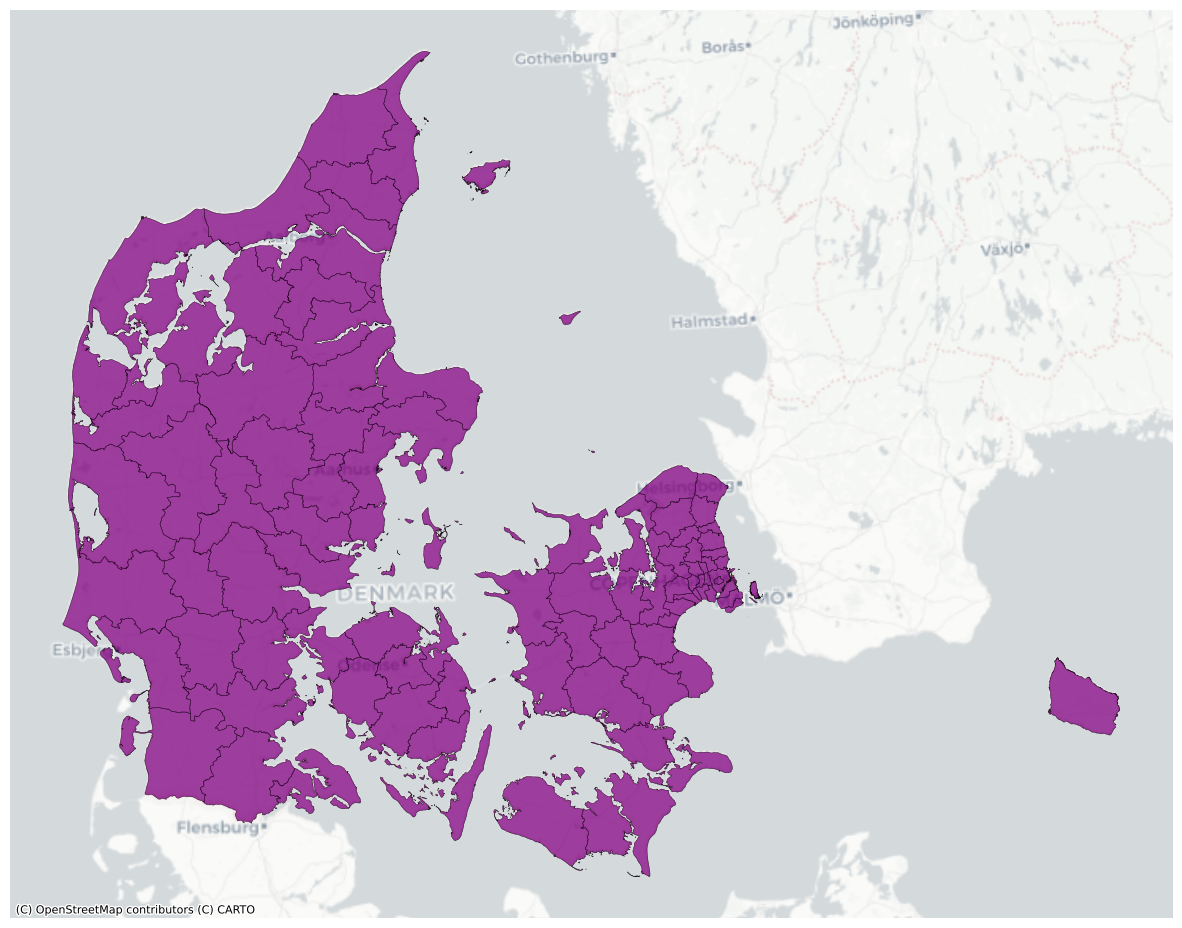

In [986]:
# Plotting municipalities
ax = gdf.plot(facecolor='purple', edgecolor='black', alpha=0.5, figsize=(15,15), linewidth=0.3)

cx.add_basemap(ax, crs=gdf.crs, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()

## Spatial analysis (year 2010)

In [987]:
gdf_2010 = gdf[gdf["year"] == 2010]
gdf_2010.head()

,municipality,year,totalCrimes,totalPopulation,geometry
0,Næstved,2010,6192,81112,"MULTIPOLYGON (((672902.45 6143708.87, 672880.8..."
2,Slagelse,2010,7450,77475,"MULTIPOLYGON (((654675.25 6154223.21, 654636.5..."
4,Hedensted,2010,2608,45982,"MULTIPOLYGON (((563379.45 6175110.36, 563346.5..."
6,Haderslev,2010,4520,56346,"MULTIPOLYGON (((516449.61 6137370.13, 516423.3..."
8,Tønder,2010,2976,39710,"MULTIPOLYGON (((482562.4 6122027.62, 482507.56..."


In [988]:
# create crime rate column (Crimes / Population)
gdf_2010['pct_crime'] = gdf_2010['totalCrimes'] / gdf_2010['totalPopulation'] * 100

# standardize crime rate
gdf_2010['pct_crime_std'] = (
    gdf_2010['pct_crime'] - gdf_2010['pct_crime'].mean()
) / gdf_2010['pct_crime'].std()

In [989]:
gdf_2010.head()

,municipality,year,totalCrimes,totalPopulation,geometry,pct_crime,pct_crime_std
0,Næstved,2010,6192,81112,"MULTIPOLYGON (((672902.45 6143708.87, 672880.8...",7.633889,-0.187291
2,Slagelse,2010,7450,77475,"MULTIPOLYGON (((654675.25 6154223.21, 654636.5...",9.616005,0.606040
4,Hedensted,2010,2608,45982,"MULTIPOLYGON (((563379.45 6175110.36, 563346.5...",5.671785,-0.972613
6,Haderslev,2010,4520,56346,"MULTIPOLYGON (((516449.61 6137370.13, 516423.3...",8.021865,-0.032006
8,Tønder,2010,2976,39710,"MULTIPOLYGON (((482562.4 6122027.62, 482507.56...",7.494334,-0.243147


In [990]:
gdf_2010.describe()

,year,totalCrimes,totalPopulation,pct_crime,pct_crime_std
count,98.0,98.000000,98.000000,98.000000,9.800000e+01
mean,2010.0,5381.428571,56475.887755,8.101831,3.367488e-16
std,0.0,10240.363713,62925.301713,2.498474,1.000000e+00
min,2010.0,52.000000,1969.000000,2.605180,-2.200004e+00
25%,2010.0,2522.750000,29997.750000,6.503443,-6.397460e-01
50%,2010.0,3216.000000,43475.000000,7.744968,-1.428324e-01
75%,2010.0,5338.000000,59733.000000,9.555937,5.819976e-01
max,2010.0,94792.000000,528208.000000,17.945961,3.940057e+00


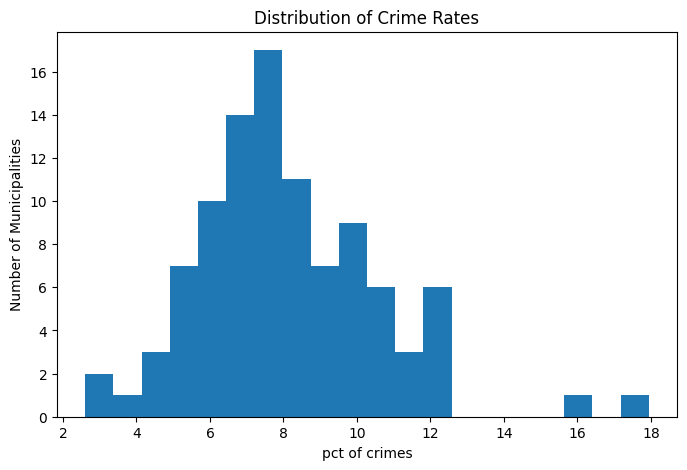

In [991]:
# Distribution of crime_rate
plt.figure(figsize=(8,5))
plt.hist(gdf_2010['pct_crime'], bins=20)

plt.xlabel('pct of crimes')
plt.ylabel('Number of Municipalities')
plt.title('Distribution of Crime Rates')
plt.show()

In [992]:
gdf_2010[gdf_2010['pct_crime'] > 15] 

,municipality,year,totalCrimes,totalPopulation,geometry,pct_crime,pct_crime_std
34,København,2010,94792,528208,"MULTIPOLYGON (((723090.01 6171801.78, 723090.6...",17.945961,3.940057
52,Tårnby,2010,6439,40383,"MULTIPOLYGON (((729600.3 6172549.66, 729596.42...",15.944828,3.139115


## Spatial autocorrelation Analysis

### Spatial weights

In [993]:
# create queen contiquity weights
spatial_weights = weights.Queen.from_dataframe(gdf_2010, idVariable="municipality")



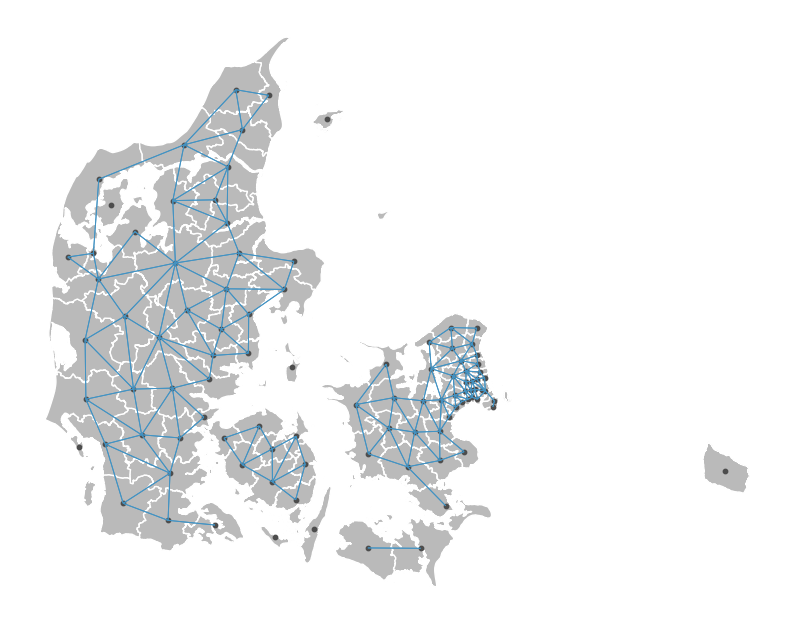

In [994]:
plot_spatial_weights(spatial_weights, gdf_2010, indexed_on='municipality');

In [995]:
# check and remove islands
islands = spatial_weights.islands
gdf_2010 = gdf_2010[~gdf_2010['municipality'].isin(islands)]
# Rebuild Queen weights
spatial_weights = weights.Queen.from_dataframe(gdf_2010, idVariable="municipality")

islands

['Bornholm', 'Ærø', 'Langeland', 'Samsø', 'Morsø', 'Fanø', 'Læsø']

In [996]:
neighbors = list(spatial_weights.cardinalities.values())
min_n_neighbors = min(neighbors)
max_n_neighbors = max(neighbors)
mean_n_neighbors = int(sum(neighbors) / len(neighbors))

print('Mean number of neighbors in denmarks municipalities: ', mean_n_neighbors)
print('Min number of neighbors in denmarks municipalities: ', min_n_neighbors)
print('Max number of neighbors in denmarks municipalities: ', max_n_neighbors)

Mean number of neighbors in denmarks municipalities:  4
Min number of neighbors in denmarks municipalities:  1
Max number of neighbors in denmarks municipalities:  9


In [997]:
spatial_weights['København']

{'Hvidovre': 1.0,
 'Herlev': 1.0,
 'Gladsaxe': 1.0,
 'Rødovre': 1.0,
 'Gentofte': 1.0,
 'Frederiksberg': 1.0,
 'Tårnby': 1.0}

In [998]:
# stadandize the spatial weights by row
spatial_weights.transform = 'R'
print(sum(spatial_weights['København'].values()))

1.0


In [999]:
spatial_weights['København']

{'Hvidovre': 0.14285714285714285,
 'Herlev': 0.14285714285714285,
 'Gladsaxe': 0.14285714285714285,
 'Rødovre': 0.14285714285714285,
 'Gentofte': 0.14285714285714285,
 'Frederiksberg': 0.14285714285714285,
 'Tårnby': 0.14285714285714285}

### Global spatial autocorrelation

Moran's I: 0.25414033459018587
P-value: 0.003


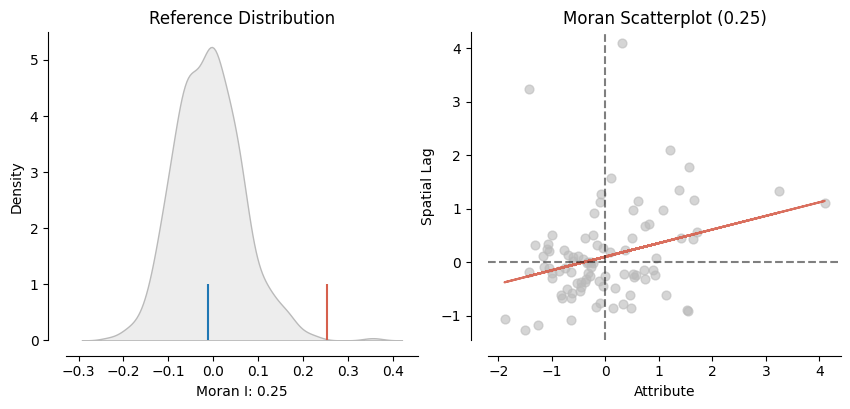

In [1000]:
# Calculate Moran's I
mi = esda.Moran(gdf_2010['pct_crime'], spatial_weights)

print("Moran's I:", mi.I)

print("P-value:", mi.p_sim)

plot_moran(mi);

### Local spatial autocorrelation

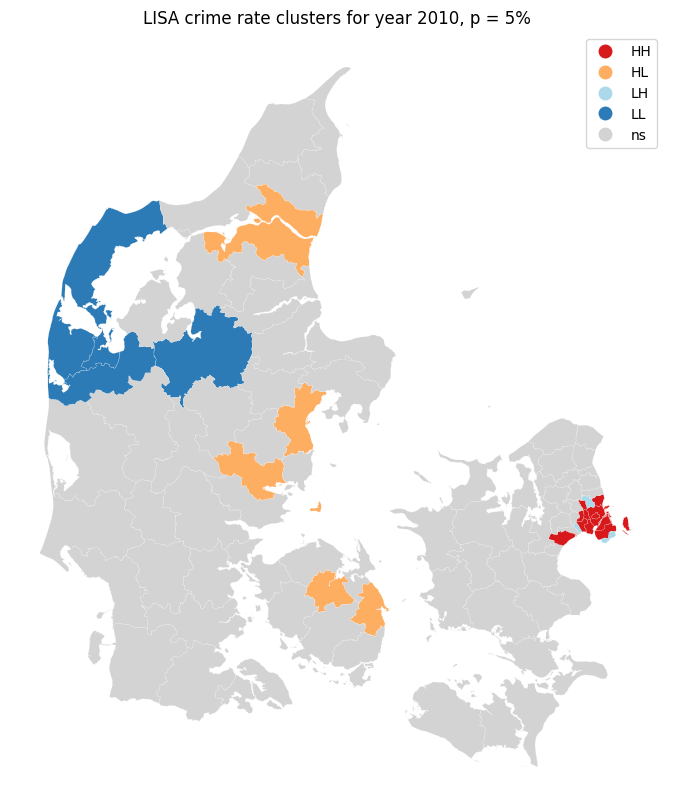

In [1001]:
lisa = esda.Moran_Local(y = gdf_2010['pct_crime'], 
                        w = spatial_weights)

fig, ax = plt.subplots(1, figsize=(10,10))

lisa_cluster(
    lisa,
    gdf_2010,
    p=0.05,
    ax=ax
)

plt.title("LISA crime rate clusters for year 2010, p = 5%");

## Spatial analysis (year 2025)

In [1002]:
gdf_2025 = gdf[gdf["year"] == 2025]
gdf_2025.head()

,municipality,year,totalCrimes,totalPopulation,geometry
1,Næstved,2025,5821,84895,"MULTIPOLYGON (((672902.45 6143708.87, 672880.8..."
3,Slagelse,2025,5571,80481,"MULTIPOLYGON (((654675.25 6154223.21, 654636.5..."
5,Hedensted,2025,1914,48167,"MULTIPOLYGON (((563379.45 6175110.36, 563346.5..."
7,Haderslev,2025,3007,55354,"MULTIPOLYGON (((516449.61 6137370.13, 516423.3..."
9,Tønder,2025,1801,36399,"MULTIPOLYGON (((482562.4 6122027.62, 482507.56..."


In [1003]:
# create crime rate column (Crimes / Population)
gdf_2025['pct_crime'] = gdf_2025['totalCrimes'] / gdf_2025['totalPopulation'] * 100

# standardize crime rate
gdf_2025['pct_crime_std'] = (
    gdf_2025['pct_crime'] - gdf_2025['pct_crime'].mean()
) / gdf_2025['pct_crime'].std()

In [1004]:
gdf_2025.head()

,municipality,year,totalCrimes,totalPopulation,geometry,pct_crime,pct_crime_std
1,Næstved,2025,5821,84895,"MULTIPOLYGON (((672902.45 6143708.87, 672880.8...",6.856705,0.788770
3,Slagelse,2025,5571,80481,"MULTIPOLYGON (((654675.25 6154223.21, 654636.5...",6.922131,0.822894
5,Hedensted,2025,1914,48167,"MULTIPOLYGON (((563379.45 6175110.36, 563346.5...",3.973675,-0.714941
7,Haderslev,2025,3007,55354,"MULTIPOLYGON (((516449.61 6137370.13, 516423.3...",5.432308,0.045843
9,Tønder,2025,1801,36399,"MULTIPOLYGON (((482562.4 6122027.62, 482507.56...",4.947938,-0.206791


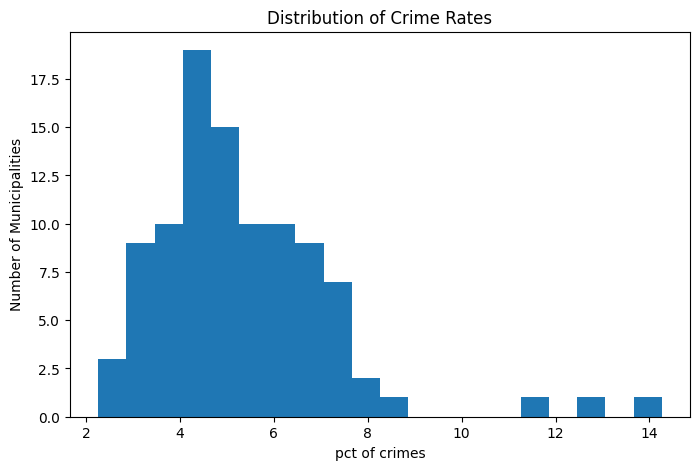

In [1005]:
# Distribution of crime_rate
plt.figure(figsize=(8,5))
plt.hist(gdf_2025['pct_crime'], bins=20)

plt.xlabel('pct of crimes')
plt.ylabel('Number of Municipalities')
plt.title('Distribution of Crime Rates')
plt.show()

In [1006]:
# create queen contiquity weights
spatial_weights = weights.Queen.from_dataframe(gdf_2025, idVariable="municipality")

In [1007]:
# check and remove islands
islands = spatial_weights.islands
gdf_2025 = gdf_2025[~gdf_2025['municipality'].isin(islands)]

# Rebuild Queen weights
spatial_weights = weights.Queen.from_dataframe(gdf_2025, idVariable="municipality")

In [1008]:
neighbors = list(spatial_weights.cardinalities.values())
min_n_neighbors = min(neighbors)
max_n_neighbors = max(neighbors)
mean_n_neighbors = int(sum(neighbors) / len(neighbors))

print('Mean number of neighbors in denmarks municipalities: ', mean_n_neighbors)
print('Min number of neighbors in denmarks municipalities: ', min_n_neighbors)
print('Max number of neighbors in denmarks municipalities: ', max_n_neighbors)

Mean number of neighbors in denmarks municipalities:  4
Min number of neighbors in denmarks municipalities:  1
Max number of neighbors in denmarks municipalities:  9


In [1009]:
spatial_weights['København']

{'Hvidovre': 1.0,
 'Herlev': 1.0,
 'Gladsaxe': 1.0,
 'Rødovre': 1.0,
 'Gentofte': 1.0,
 'Frederiksberg': 1.0,
 'Tårnby': 1.0}

In [1010]:
# stadandize the spatial weights by row
spatial_weights.transform = 'R'
print(sum(spatial_weights['København'].values()))

1.0


In [1011]:
spatial_weights['København']

{'Hvidovre': 0.14285714285714285,
 'Herlev': 0.14285714285714285,
 'Gladsaxe': 0.14285714285714285,
 'Rødovre': 0.14285714285714285,
 'Gentofte': 0.14285714285714285,
 'Frederiksberg': 0.14285714285714285,
 'Tårnby': 0.14285714285714285}

### Global spatial autocorrelation

Moran's I: 0.3086317030257196
P-value: 0.001


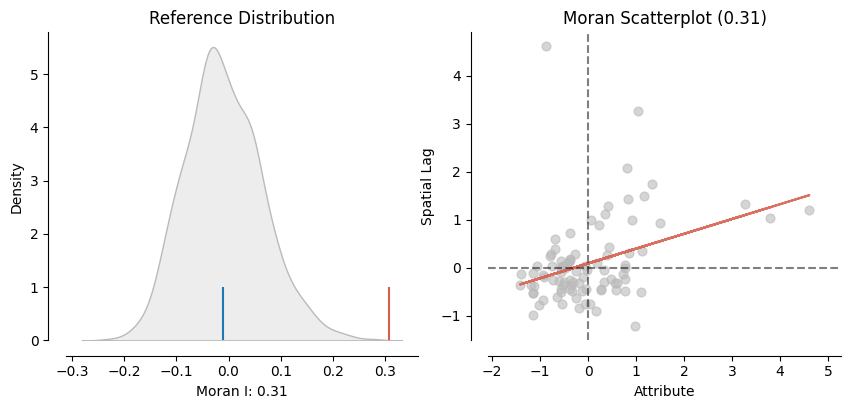

In [1012]:
# Calculate Moran's I
mi = esda.Moran(gdf_2025['pct_crime'], spatial_weights)

print("Moran's I:", mi.I)

print("P-value:", mi.p_sim)

# ready-implemented function for Moran scatterplot
plot_moran(mi);

### Local spatial autocorrelation

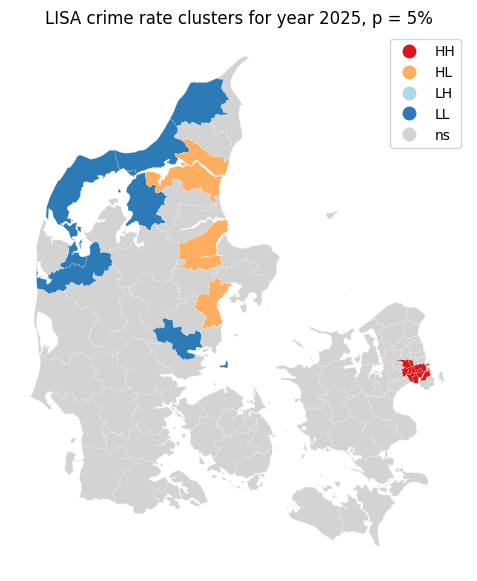

In [1013]:
lisa = esda.Moran_Local(y = gdf_2025['pct_crime'], 
                        w = spatial_weights)

fig, ax = plt.subplots(1, figsize=(7,7))

lisa_cluster(lisa, gdf_2025, p=0.05, ax=ax)

plt.title("LISA crime rate clusters for year 2025, p = 5%");